## Notebook with analysis pertaining to Figure 2
Code blocks are not in alphabetical order of panel labels, but section labels match pabel labels in the figure.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

plt.rcParams['axes.spines.top'] = False # remove top spine
plt.rcParams['axes.spines.right'] = False # remove right spine
plt.rcParams['pdf.fonttype'] = 42 # Set the fonttype to export fonts as font files
plt.rcParams['font.family'] = 'Arial'
global_fontsize = 12

In [ ]:
# From annotations/add_annot_to_clusters.ipynb
pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")
pdb_clusters['chain_id_0'] = pdb_clusters['chain_id_0'].fillna('NA')
pdb_clusters['chain_id_1'] = pdb_clusters['chain_id_1'].fillna('NA')
# From annotations/create_cluster_summary.ipynb
cluster_summary = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_cluster_summary.tsv", sep="\t")

/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_23289/2125341905.py:1: DtypeWarning: Columns (32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")


In [ ]:
# Lable singleton clusters
int_clust_size = pdb_clusters.groupby('intcluster')['old_complex_id'].count().to_frame()
int_clust_size.columns = ["cluster_size"]
singleton_ids = list(set(int_clust_size[int_clust_size["cluster_size"] == 1].index))

cluster_summary.loc[:, "singleton"] = "Non-singleton"
cluster_summary.loc[cluster_summary["intcluster"].isin(singleton_ids), "singleton"] = "Singleton"

## Panel a

In [ ]:
# From benchmarking/create_ord-ord_benchmark_dataset.ipynb
ddi = pd.read_csv('/Volumes/imb-luckgr/projects/interface_clustering/datasets/benchmarking/ddi_clusters.csv')
# From benchmarking/create_dis-ord_benchmark_dataset.ipynb
dmi = pd.read_csv('/Volumes/imb-luckgr/projects/interface_clustering/datasets/benchmarking/dmi_clusters.csv')
pdb_clusters['chains'] = pdb_clusters[['chain_id_0','chain_id_1']].apply(lambda x: '_'.join(sorted([str(y) for y in x])), axis=1)
pdb_clusters.loc[:,'simple_pdb_id'] = [x[:4] for x in pdb_clusters['pdb_id']]
pdb_clusters['full_lookup_id'] = pdb_clusters[['simple_pdb_id','chains']].apply(lambda x: '_'.join([str(y) for y in x]), axis=1)

In [ ]:
# Results from re-clustering of PDB dimer representatives with Foldseek-Interface with TM-score threshold of 0.5
intclust05 = pd.read_csv("/Users/stromjoe/Downloads/multimertm_05.tsv", sep="\t", header=None)
intclust05.columns = ["representative","member"]
intclust05["memcomplexid"] = [int(x.split("DI")[0]) for x in intclust05["member"]]
intclust05["intcluster05"] = pd.factorize(intclust05["representative"])[0]
intclust05["dimercluster"] = intclust05["memcomplexid"].map(dict(zip(pdb_clusters["old_complex_id"], pdb_clusters["dimercluster"])))
pdb_clusters["intcluster05"] = pdb_clusters["dimercluster"].map(dict(zip(intclust05["dimercluster"], intclust05["intcluster05"])))

# Results from re-clustering of PDB dimer representatives with Foldseek-Interface with TM-score threshold of 0.3
intclust03 = pd.read_csv("/Users/stromjoe/Downloads/multimertm_03.tsv", sep="\t", header=None)
intclust03.columns = ["representative","member"]
intclust03["memcomplexid"] = [int(x.split("DI")[0]) for x in intclust03["member"]]
intclust03["intcluster03"] = pd.factorize(intclust03["representative"])[0]
intclust03["dimercluster"] = intclust03["memcomplexid"].map(dict(zip(pdb_clusters["old_complex_id"], pdb_clusters["dimercluster"])))
pdb_clusters["intcluster03"] = pdb_clusters["dimercluster"].map(dict(zip(intclust03["dimercluster"], intclust03["intcluster03"])))

In [ ]:
# Merge PDB cluster assignments to order-order benchmark dataset
ddi.loc[:,'chains'] = ddi[['chainA','chainB']].apply(lambda x: '_'.join(sorted([str(y) for y in x])), axis=1)
ddi.loc[:,'full_lookup_id'] = ddi[['PdbID','chains']].apply(lambda x: '_'.join([str(y) for y in x]), axis=1)
ddi_merge = pd.merge(ddi, pdb_clusters, on='full_lookup_id', how='left')

print(ddi_merge.shape[0])
print(ddi_merge.loc[ddi_merge['intcluster'].isna(),["PdbID","chains_x"]])
print(ddi_merge[ddi_merge["IFID"].duplicated(keep=False)])
ddi_merge.drop_duplicates(subset="IFID", keep="first", inplace=True)
ddi_merge.dropna(subset="intcluster", axis=0, inplace=True)
print(ddi_merge.shape[0])

In [ ]:
# Calculate Adjusted Rand Score for cluster assignments from PDB interface clustering with TM-score thresholds of 0.5, 0.4, and 0.3
print(round(adjusted_rand_score(ddi_merge.trueClusters, ddi_merge.intcluster05), 3))
print(ddi_merge['intcluster05'].nunique(), ' ', ddi_merge['trueClusters'].nunique())

print(round(adjusted_rand_score(ddi_merge.trueClusters, ddi_merge.intcluster), 3))
print(ddi_merge['intcluster'].nunique(), ' ', ddi_merge['trueClusters'].nunique())

print(round(adjusted_rand_score(ddi_merge.trueClusters, ddi_merge.intcluster03), 3))
print(ddi_merge['intcluster03'].nunique(), ' ', ddi_merge['trueClusters'].nunique())

In [ ]:
# Merge PDB cluster assignments to disorder-order benchmark dataset
dmi.loc[:,'chains'] = dmi[['motif chain','domain chain']].apply(lambda x: '_'.join(sorted([str(y) for y in x])), axis=1)
dmi.loc[:,'full_lookup_id'] = dmi[['pdb_id','chains']].apply(lambda x: '_'.join([str(y) for y in x]), axis=1)
dmi_merge = pd.merge(dmi, pdb_clusters, on='full_lookup_id', how='left')

print(dmi_merge.shape[0])
print(dmi_merge.loc[dmi_merge['intcluster'].isna(),["pdb_id_x","chains_x"]])
print(dmi_merge.loc[dmi_merge["IFID"].duplicated(keep=False), ["pdb_id_x","intcluster", "chains_x"]])
dmi_merge.drop_duplicates(subset="IFID", keep="first", inplace=True)
dmi_merge.dropna(subset="intcluster", axis=0, inplace=True)
print(dmi_merge.shape[0])

In [ ]:
# Calculate Adjusted Rand Score for cluster assignments from PDB interface clustering with TM-score thresholds of 0.5, 0.4, and 0.3
print(round(adjusted_rand_score(dmi_merge.trueClusters, dmi_merge.intcluster05), 3))
print(dmi_merge['intcluster05'].nunique(), ' ', dmi_merge['trueClusters'].nunique())

print(round(adjusted_rand_score(dmi_merge.trueClusters, dmi_merge.intcluster), 3))
print(dmi_merge['intcluster'].nunique(), ' ', dmi_merge['trueClusters'].nunique())

print(round(adjusted_rand_score(dmi_merge.trueClusters, dmi_merge.intcluster03), 3))
print(dmi_merge['intcluster03'].nunique(), ' ', dmi_merge['trueClusters'].nunique())

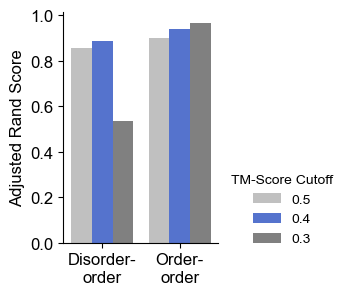

In [ ]:
# Plot ARS
ars = [0.855, 0.886, 0.537, 0.902, 0.942, 0.967]
labels = ["Disorder-\norder","Disorder-\norder","Disorder-\norder","Order-\norder","Order-\norder","Order-\norder"]
cutoffs = ["0.5","0.4","0.3","0.5","0.4","0.3"]

plot_df = pd.DataFrame({"ars":ars, "labels":labels, "cutoffs":cutoffs})

fig, ax = plt.subplots(figsize=(2,3))
sns.barplot(data=plot_df, x="labels", y="ars", hue="cutoffs", palette=["silver","royalblue","gray"], ax=ax)
ax.legend(loc=0, bbox_to_anchor=(1.0,0.35), frameon=False, fontsize=10, title="TM-Score Cutoff")
ax.set_xlabel(None)
ax.set_ylabel("Adjusted Rand Score", fontsize=12)
ax.tick_params(axis="both", labelsize=12)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/pdbifclust_bmark_ars.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/pdbifclust_bmark_ars.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel f

In [ ]:
# Find number of interfaces per PDB assembly
if_per_assem = pdb_clusters.groupby("pdb_id").size().to_frame()
pdb_clusters["if_per_assem"] = pdb_clusters["pdb_id"].map(dict(zip(if_per_assem.index, if_per_assem.loc[:,0])))
median_if_per_assem = pdb_clusters.groupby("intcluster")["if_per_assem"].median().to_frame()
median_if_per_assem.columns = ["median_if_per_assem"]
cluster_summary["median_if_per_assem"] = cluster_summary["intcluster"].map(dict(zip(median_if_per_assem.index, median_if_per_assem.median_if_per_assem)))
cluster_summary.loc[:, "cat_median_if_per_assem"] = "1000+"
cluster_summary.loc[cluster_summary["median_if_per_assem"] < 1000, "cat_median_if_per_assem"] = "100-1000"
cluster_summary.loc[cluster_summary["median_if_per_assem"] < 100, "cat_median_if_per_assem"] = "10-100"
cluster_summary.loc[cluster_summary["median_if_per_assem"] < 10, "cat_median_if_per_assem"] = "2-10"
cluster_summary.loc[cluster_summary["median_if_per_assem"] == 1, "cat_median_if_per_assem"] = "1"

In [6]:
num_if_per_pdb = pdb_clusters.groupby("pdb_id")["old_complex_id"].size()
single_dimers = list(set(num_if_per_pdb[num_if_per_pdb == 1].index))
pdb_clusters.loc[:, "single_dimer"] = 0
pdb_clusters.loc[pdb_clusters["pdb_id"].isin(single_dimers), "single_dimer"] = 1

singleton_ifs = pdb_clusters[pdb_clusters["intcluster"].isin(singleton_ids)]
nonsingle_ifs = pdb_clusters[~pdb_clusters["intcluster"].isin(singleton_ids)]

print(pdb_clusters["single_dimer"].sum() / len(pdb_clusters))

print(singleton_ifs["single_dimer"].sum() / len(singleton_ifs))
print(nonsingle_ifs["single_dimer"].sum() / len(nonsingle_ifs))

0.03113427746214639
0.2851370725985141
0.029247705024679375


77167


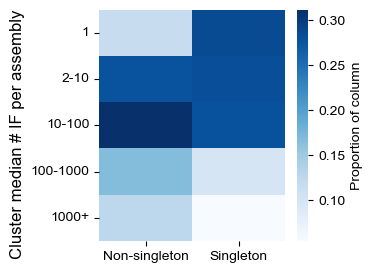

In [ ]:
# Heatmap of number of interfaces per assembly for singletons and non-singletons
num_singletons = len(cluster_summary[cluster_summary["singleton"] == "Singleton"])
num_nonsingle = len(cluster_summary[cluster_summary["singleton"] == "Non-singleton"])
print(num_singletons + num_nonsingle)

index_order = ["1","2-10","10-100","100-1000","1000+"]

plot_data = cluster_summary.groupby(["singleton","cat_median_if_per_assem"]).size().to_frame()
plot_data.reset_index(inplace=True)
plot_data.columns = ["singleton","cat_median_if_per_assem","count"]
plot_data = pd.pivot(data=plot_data, index="cat_median_if_per_assem", columns="singleton", values="count")
plot_data["Singleton"] = plot_data["Singleton"] / num_singletons
plot_data["Non-singleton"] = plot_data["Non-singleton"] / num_nonsingle
plot_data = plot_data.reindex(index_order)

fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(data=plot_data, cmap=sns.color_palette('Blues', as_cmap=True), cbar_kws={'label':'Proportion of column'}, ax=ax)
ax.set_ylabel("Cluster median # IF per assembly", fontsize=12, loc='top')
ax.set_xlabel(None)
ax.tick_params(axis='both', labelsize=10)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/singleton_heatmap_ifperassembly.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/singleton_heatmap_ifperassembly.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel d

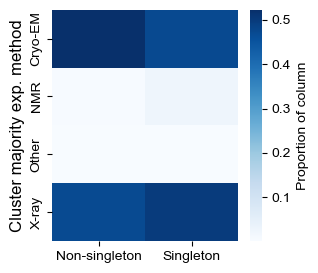

In [ ]:
# Heatmap of experimental methods for singletons and non-singletons
cluster_summary["top_exptmethod"].value_counts()
cluster_summary.loc[:, "top_exptmethod_cleaned"] = "Other"
cluster_summary.loc[cluster_summary["top_exptmethod"] == "ELECTRON MICROSCOPY", "top_exptmethod_cleaned"] = "Cryo-EM"
cluster_summary.loc[cluster_summary["top_exptmethod"] == "X-RAY DIFFRACTION", "top_exptmethod_cleaned"] = "X-ray"
cluster_summary.loc[cluster_summary["top_exptmethod"] == "SOLUTION NMR", "top_exptmethod_cleaned"] = "NMR"
cluster_summary.loc[cluster_summary["top_exptmethod"] == "SOLID-STATE NMR", "top_exptmethod_cleaned"] = "NMR"

plot_data = cluster_summary.groupby(["singleton","top_exptmethod_cleaned"]).size().to_frame()
plot_data.reset_index(inplace=True)
plot_data.columns = ["singleton","top_exptmethod_cleaned","count"]
plot_data = pd.pivot(data=plot_data, index="top_exptmethod_cleaned", columns="singleton", values="count")
plot_data["Singleton"] = plot_data["Singleton"] / num_singletons
plot_data["Non-singleton"] = plot_data["Non-singleton"] / num_nonsingle

fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(data=plot_data, cmap=sns.color_palette('Blues', as_cmap=True), cbar_kws={'label':'Proportion of column'}, ax=ax)
ax.set_ylabel("Cluster majority exp. method", fontsize=12)
ax.set_xlabel(None)
ax.tick_params(axis='both', labelsize=10)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/singleton_heatmap_expermethod.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/singleton_heatmap_expermethod.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel c

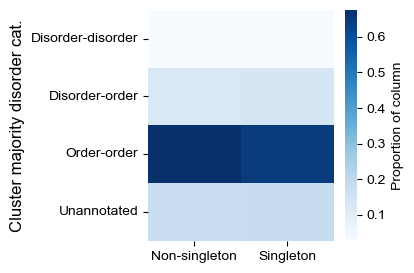

In [ ]:
# Heatmap of disorder percentages of singletons and non-singletons
plot_data = cluster_summary.groupby(["singleton","top_discat"]).size().to_frame()
plot_data.reset_index(inplace=True)
plot_data.columns = ["singleton","top_discat","count"]
plot_data = pd.pivot(data=plot_data, index="top_discat", columns="singleton", values="count")
plot_data["Singleton"] = plot_data["Singleton"] / num_singletons
plot_data["Non-singleton"] = plot_data["Non-singleton"] / num_nonsingle

fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(data=plot_data, cmap=sns.color_palette('Blues', as_cmap=True), cbar_kws={'label':'Proportion of column'}, ax=ax)
ax.set_ylabel("Cluster majority disorder cat.", fontsize=12)
ax.set_xlabel(None)
ax.tick_params(axis='both', labelsize=10)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/singleton_heatmap_disorder.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/singleton_heatmap_disorder.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

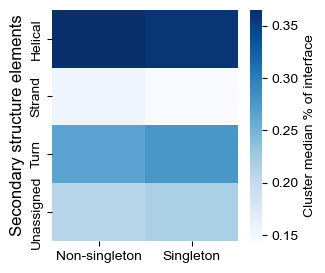

In [ ]:
# Heatmap of secondary structure elements for singletons and non-singletons
plot_data = cluster_summary.groupby("singleton")[['median_helixfrac', 'median_betafrac', 'median_bendturnfrac','median_unassignfrac']].mean()
plot_data.columns = ["Helical", "Strand", "Turn", "Unassigned"]
plot_data = plot_data.T

fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(data=plot_data, cmap=sns.color_palette('Blues', as_cmap=True), cbar_kws={'label':'Cluster median % of interface'}, ax=ax)
ax.set_ylabel("Secondary structure elements", fontsize=12)
ax.set_xlabel(None)
ax.tick_params(axis='both', labelsize=10)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/singleton_heatmap_sspct.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/singleton_heatmap_sspct.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel e

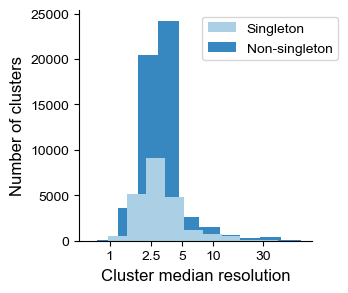

In [ ]:
# Distributions of median cluster resolution for singletons and non-singletons
palette = sns.color_palette('Blues', n_colors=2)
fig, ax = plt.subplots(figsize=(3,3))
ax.hist([np.log10(x) for x in cluster_summary[cluster_summary["singleton"] == "Singleton"]["median_resolution"]], color=palette[0], label="Singleton", zorder=2)
ax.hist([np.log10(x) for x in cluster_summary[cluster_summary["singleton"] == "Non-singleton"]["median_resolution"]], color=palette[1], label="Non-singleton", zorder=1)
ax.set_ylabel("Number of clusters", fontsize=12)
ax.set_xlabel("Cluster median resolution", fontsize=12)
ax.set_xticks([np.log10(1), np.log10(2.5), np.log10(5), np.log10(10), np.log10(30)])
ax.set_xticklabels(["1", "2.5", "5", "10", "30"])
ax.tick_params(axis='both', labelsize=10)
ax.legend(loc=0, bbox_to_anchor=(0.5,1.0), title=None, fontsize=10)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/singleton_histogram_resolution.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/singleton_histogram_resolution.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel g

In [12]:
num_dimer_reps = pdb_clusters.groupby("intcluster")["dimerrep"].sum()
if_singletons = list(set(num_dimer_reps[num_dimer_reps == 1].index))

cluster_qtms = cluster_summary["cluster_qtm"].to_frame()
cluster_qtms.columns = ["cluster_qtm"]
cluster_qtms_nosing = cluster_qtms[~cluster_qtms.index.isin(if_singletons)]

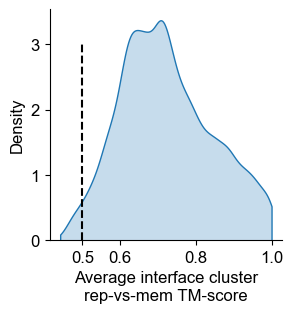

In [13]:
fig, ax = plt.subplots(figsize=(3,3))
sns.kdeplot(cluster_qtms_nosing, x="cluster_qtm", cut=0, fill=True, ax=ax)
ax.set_xticks([0.5, 0.6, 0.8, 1.0])
ax.set_xlabel("Average interface cluster\nrep-vs-mem TM-score", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.tick_params(axis='both', labelsize=12)
ax.vlines(x=0.5, ymin=0, ymax=3, color="black", linestyle="dashed")

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/cluster_tmscore_kde.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/cluster_tmscore_kde.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel h

In [ ]:
# Find example of cluster with low average cluster TM-score and small interfaces to visualize
cluster_summary[cluster_summary["cluster_qtm"] < 0.5].sort_values(by="median_ifsize", ascending=True)[["cluster_qtm","median_ifsize","intcluster"]]

,cluster_qtm,median_ifsize,intcluster
11919,0.446,8.0,11919
35897,0.494,8.0,35897
46503,0.465,8.0,46503
45043,0.499,8.0,45043
13330,0.452,8.0,13330
...,...,...,...
41959,0.481,83.0,41959
31418,0.485,84.0,31418
432,0.471,91.0,432
388,0.498,102.0,388


## Panel i

In [ ]:
# Clean the labels of experimental methods
pdb_clusters_nonaexp = pdb_clusters.dropna(subset="pdb_expt_method", axis=0)
print(pdb_clusters_nonaexp["pdb_expt_method"].value_counts())

pdb_clusters_nonaexp.loc[:, "pdb_expt_method_cleaned"] = ""
pdb_clusters_nonaexp.loc[pdb_clusters_nonaexp["pdb_expt_method"] == "ELECTRON MICROSCOPY", "pdb_expt_method_cleaned"] = "CryoEM"
pdb_clusters_nonaexp.loc[pdb_clusters_nonaexp["pdb_expt_method"] == "SOLID-STATE NMR", "pdb_expt_method_cleaned"] = "Solid-state NMR"
pdb_clusters_nonaexp.loc[pdb_clusters_nonaexp["pdb_expt_method"] == "X-RAY DIFFRACTION", "pdb_expt_method_cleaned"] = "X-ray"
pdb_clusters_nonaexp.loc[pdb_clusters_nonaexp["pdb_expt_method"] == "FIBER DIFFRACTION", "pdb_expt_method_cleaned"] = "Other"
pdb_clusters_nonaexp.loc[pdb_clusters_nonaexp["pdb_expt_method"] == "SOLUTION NMR", "pdb_expt_method_cleaned"] = "Solution NMR"
pdb_clusters_nonaexp.loc[pdb_clusters_nonaexp["pdb_expt_method"] == "ELECTRON CRYSTALLOGRAPHY", "pdb_expt_method_cleaned"] = "Other"
pdb_clusters_nonaexp.loc[pdb_clusters_nonaexp["pdb_expt_method"] == "NEUTRON DIFFRACTION", "pdb_expt_method_cleaned"] = "Other"
pdb_clusters_nonaexp.loc[pdb_clusters_nonaexp["pdb_expt_method"] == "POWDER DIFFRACTION", "pdb_expt_method_cleaned"] = "Other"
pdb_clusters_nonaexp.loc[pdb_clusters_nonaexp["pdb_expt_method"] == "SOLUTION SCATTERING", "pdb_expt_method_cleaned"] = "Other"

def get_expt_method_str(x):
    return " + ".join(list(set(x["pdb_expt_method_cleaned"])))

dimer_exp_methods = pdb_clusters_nonaexp.groupby("dimercluster").apply(lambda x: get_expt_method_str(x)).to_frame()
dimer_exp_methods.columns = ["expt_method"]

exp_methods = pdb_clusters_nonaexp.groupby("intcluster").apply(lambda x: get_expt_method_str(x)).to_frame()
exp_methods.columns = ["expt_method"]

singleton_ids = list(set(int_clust_size[int_clust_size["cluster_size"] == 1].index))
exp_methods.loc[:, "singleton"] = "Not singleton"
exp_methods.loc[exp_methods.index.isin(singleton_ids), "singleton"] = "Singleton"

pdb_expt_method
ELECTRON MICROSCOPY         2167756
X-RAY DIFFRACTION            920323
SOLID-STATE NMR               16644
FIBER DIFFRACTION              3544
SOLUTION NMR                   2652
ELECTRON CRYSTALLOGRAPHY       1271
NEUTRON DIFFRACTION             195
POWDER DIFFRACTION               92
SOLUTION SCATTERING              86
Name: count, dtype: int64


/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_3735/4123990964.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdb_clusters_nonaexp.loc[:, "pdb_expt_method_cleaned"] = ""
/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_3735/4123990964.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dimer_exp_methods = pdb_clusters_nonaexp.groupby("dimercluster").apply(lambda x: get_expt_method_str(x)).to_frame()
/var/folders/8n/b4ym5rbn48v7d2

In [16]:
exp_methods["expt_method"].value_counts()

expt_method
CryoEM                                                     36060
X-ray                                                      33976
X-ray + CryoEM                                              5466
Solution NMR                                                 734
Solution NMR + X-ray                                         243
Solution NMR + X-ray + CryoEM                                187
Other                                                        101
Solid-state NMR                                               96
CryoEM + X-ray + Other                                        53
Solution NMR + CryoEM                                         35
Solid-state NMR + X-ray + CryoEM                              32
Solid-state NMR + CryoEM                                      31
X-ray + Other                                                 30
CryoEM + Other                                                15
Solution NMR + CryoEM + X-ray + Other                         15
Solid-state N

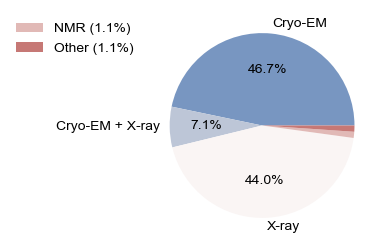

In [17]:
dimer_cryoem_pct = 95683 / 189830
dimer_xray_pct = 71052 / 189830
dimer_cryoxray_pct = 5006 / 189830
dimer_solidstatenmr_pct = 14876 / 189830
dimer_solutionnmr_pct = 1962 / 189830
dimer_other_pct = 1 - dimer_cryoem_pct - dimer_xray_pct - dimer_cryoxray_pct - dimer_solidstatenmr_pct - dimer_solutionnmr_pct

int_cryoem_pct = 36060 / 77167
int_xray_pct = 33976 / 77167
int_cryoxray_pct = 5466 / 77167
int_nmr_pct = (96 + 734) / 77167
int_other_pct = 1 - int_cryoem_pct - int_xray_pct - int_cryoxray_pct - int_nmr_pct

def func(pct):
    if pct > 2:
        return f"{pct:.1f}%"
    else:
        return ""
    
palette = sns.color_palette('vlag', n_colors=5)
    
legend_elements = [mpl.patches.Patch(facecolor=palette[3], label="NMR (1.1%)"),
                   mpl.patches.Patch(facecolor=palette[4], label="Other (1.1%)")]

fig, ax = plt.subplots(figsize=(3,3))
ax.pie([int_cryoem_pct, int_cryoxray_pct, int_xray_pct, int_nmr_pct, int_other_pct], labels=["Cryo-EM", "Cryo-EM + X-ray", "X-ray", "", ""], autopct=lambda pct: func(pct), colors=palette)
ax.legend(handles=legend_elements, loc=0, bbox_to_anchor=(0,1.0), frameon=False, title=None)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/expmethod_piechart.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/expmethod_piechart.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')